# Multiprocessing on GPU
In this tutorial, the idea is to parallelize the reading of several HDF5 files across different processes and to perform the azimuthal integration on the GPU together with Bitshuffle-LZ4 decompression.
The scale of this problem involves 1000 files containing 1000 frames each of 4Mpx resolution—that's one million frames total. The reduced data will be 1000×1000×1000 in single-precision float format.
This is an extreme case where we'll explore how to utilize all available computer resources. The first step is to determine the system topology:

**Lenovo P620 Workstation**
- 1 processor: AMD Threadripper PRO 3975WX, 32 cores with hyperthreading (64 threads) across 4 NUMA sub-domains. 450W TDP.
- 2 GPUs:
  * NVIDIA RTX A5000 (8192 CUDA-cores, 24 GB GDDR6, 16xPCIe4, 230W)
  * NVIDIA Quadro P2200 (1280 CUDA-cores, 5GB GDDR5, 16xPCIe3, 75W)

**Disclaimer:**
- We use the `multiprocess` library instead of `multiprocessing` to demonstrate this procedure within a Jupyter notebook.
- We use `SharedArray` to provide a natural way of sharing the result array in memory between processes.

Exporting format `png' to file `/tmp/topo.png'
Failed to open /tmp/topo.png for writing (File exists)


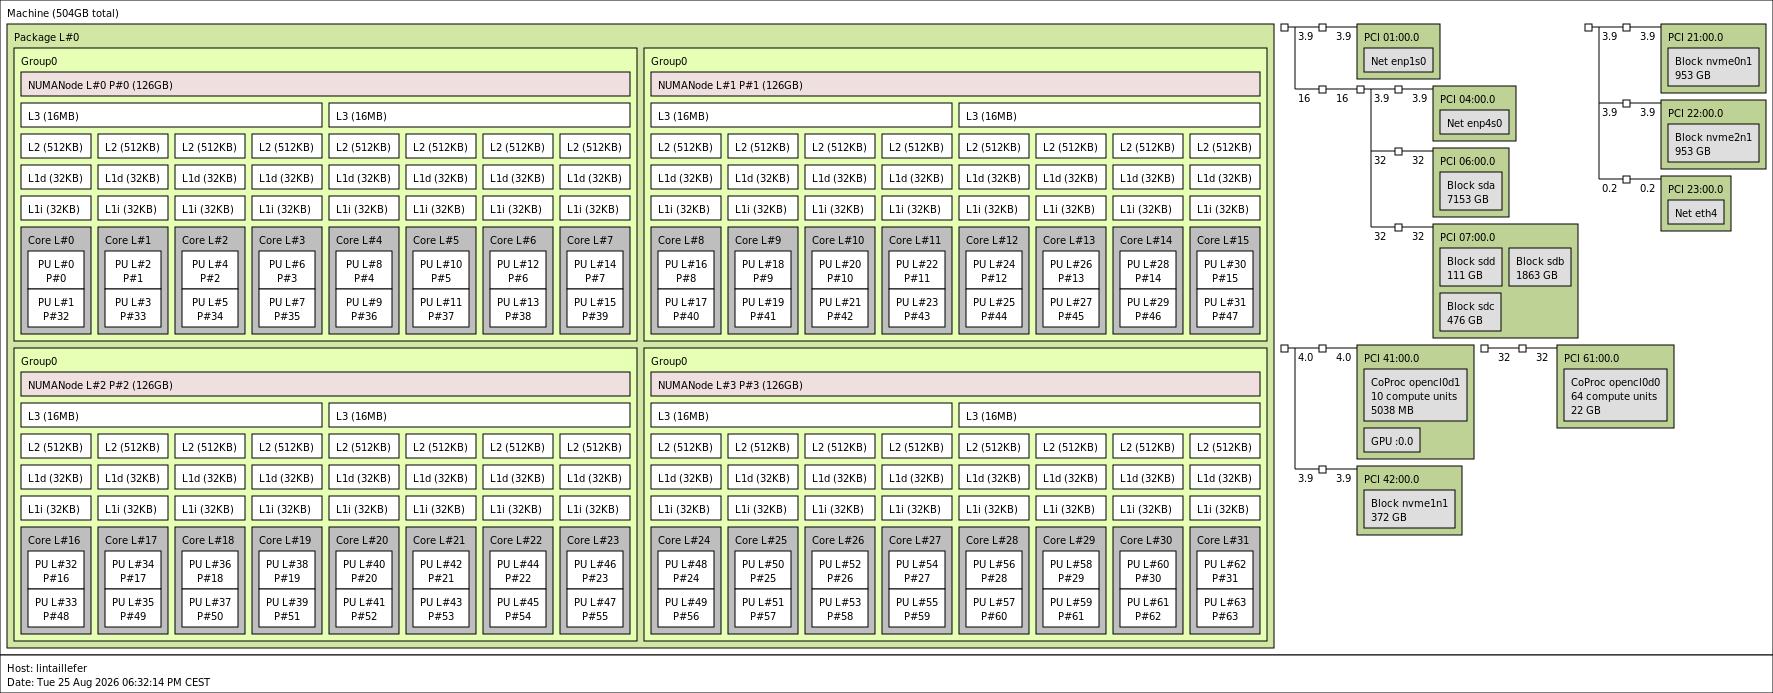

In [1]:
%matplotlib inline
# use `widget` for better user experience; `inline` is for documentation generation

#Topology of the computer:
!lstopo /tmp/topo.png
from IPython.display import Image
Image(filename='/tmp/topo.png') 

In [2]:
import os
import glob
import time
import json
from matplotlib.pyplot import subplots
import multiprocess
from multiprocess import Process
if "mpctx" in globals():
    mpctx = multiprocess.get_context('spawn')
else:
    multiprocess.set_start_method('spawn')
    mpctx = multiprocess.get_context('spawn')
import numpy
import hdf5plugin
import h5py
import pyFAI
print("pyFAI version: ", pyFAI.version)
import SharedArray
from silx.opencl import ocl
from silx.opencl.codec.bitshuffle_lz4 import BitshuffleLz4
import collections
# import bitshuffle_lz4
Item = collections.namedtuple("Item", "index filename")
MAIN_PROCESS = multiprocess.parent_process() is None
print(ocl)

pyFAI version:  2026.8.0-dev0
OpenCL devices:
[0] NVIDIA CUDA: (0,0) NVIDIA RTX A5000, (0,1) Quadro P2200
[1] Portable Computing Language: (1,0) cpu-haswell-AMD Ryzen Threadripper PRO 3975WX 32-Cores
[2] Intel(R) OpenCL: (2,0) AMD Ryzen Threadripper PRO 3975WX 32-Cores


In [3]:
#This cell contains the parameters for all the processing
params = {
    "DEVICES": [[0,0], [0,0], [0,0], [0,0], [0,0], [0,0],   # 6 instances on the large GPU
                [0,1], [0,1], [0,1],                        # 3 instances on the small GPU
                [2,0]],                                     # 1 instance on the CPU-cores
    "NWORKERS": 10,
    "FRAME_PER_FILE": 1000,
    "NFILES" : 1000,
    "NBINS" : 1000,
    "DETECTOR":"Eiger_4M",
    "pathname" : "/tmp/big_%04d.h5",
    "pathmask" : "/tmp/big_????.h5",
    "dtype" : "float32",
    "SHARED_NAME" : "shm://multigpu",
    "array_shape" : [1000, 1000, 1000],
    }
with open("param.json", "w") as w: w.write(json.dumps(params, indent=2))
for k,v in params.items():
    globals()[k] = v

In [4]:
def build_integrator(detector=DETECTOR):
    "Build an azimuthal integrator with a dummy geometry"
    geo = {"detector": detector, 
           "wavelength": 1e-10} 
    ai = pyFAI.load(geo)
    return ai

In [5]:
# Generate a set of files
def generate_one_frame(ai, unit="q_nm^-1", dtype="uint32"):
    """Prepare a frame with little count so that it compresses well"""
    qmax = ai.array_from_unit(unit=unit).max()
    q = numpy.linspace(0, qmax, 100)
    img = ai.calcfrom1d(q, 100/(1+q*q))
    frame = numpy.random.poisson(img).astype(dtype)
    return frame

def generate_files(img):
    cmp = hdf5plugin.Bitshuffle()
    filename = pathname%0
    shape = img.shape
    with h5py.File(filename, "w") as h:
        ds = h.create_dataset("data", shape=(FRAME_PER_FILE,)+shape, chunks=(1,)+shape, dtype=img.dtype, **cmp) 
        for i in range(FRAME_PER_FILE):
            ds[i] = img + i%500 #Each frame has a different value to prevent caching effects
    res = [filename]
    for i in range(1, NFILES):
        new_file = pathname%i
        os.link(filename,new_file)
        res.append(new_file)
    return res

# Create a set of files with dummy data in them:
if len(glob.glob(pathmask)) == NFILES: 
    input_files = glob.glob(pathmask)
    input_files.sort()
else:
    for f in glob.glob(pathmask):
        os.remove(f)
    input_files = generate_files(generate_one_frame(build_integrator(DETECTOR)))
input_files[:5]

['/tmp/big_0000.h5',
 '/tmp/big_0001.h5',
 '/tmp/big_0002.h5',
 '/tmp/big_0003.h5',
 '/tmp/big_0004.h5']

In [6]:
#This is allows to create and destroy shared numpy arrays

def create_shared_array(shape, dtype="float32", name=SHARED_NAME):
    if name in [i.name.decode() for i in  SharedArray.list()]:
        ary = SharedArray.create(name, shape, dtype=dtype)
    else:
        ary = SharedArray.attach(name)
    return ary

def release_shared(name=SHARED_NAME):
    if MAIN_PROCESS:
        SharedArray.delete(name)

result_array = create_shared_array(array_shape, dtype, SHARED_NAME)

In [7]:
def worker(rank, queue, shm_name, counter):
    """Function representing one worker, used in a pool of worker.
    
    :param rank: integer, index of the worker.
    :param queue: input queue, expects Item with index and name of the file to process
    :param shm_name: name of the output shared memory to put integrated intensities
    :param counter: decremented when quits
    :return: nothing, used in a process.
    """
    def new_engine(engine, wg):
        "Change workgroup size of an engine"
        return engine.__class__((engine._data, engine._indices, engine._indptr), 
                              engine.size, empty=engine.empty, unit=engine.unit, 
                              bin_centers=engine.bin_centers, azim_centers = engine.azim_centers,  
                              ctx=engine.ctx, block_size=wg)
    #imports:
    import pyFAI
    import numpy
    import SharedArray
    import h5py
    import json
    from silx.opencl.codec.bitshuffle_lz4 import BitshuffleLz4    #load parameters:
    for k,v in json.load(open("param.json")).items():
        globals()[k] = v
    #Start up the integrator:
    ai = pyFAI.load({"detector": DETECTOR, 
                     "wavelength": 1e-10, 
                     "rot3":0})
    blank = numpy.zeros(ai.detector.shape, dtype="uint32")
    method = ("full", "csr", "opencl", DEVICES[rank%len(DEVICES)])
    res = ai.integrate1d(blank, NBINS, method=method)
    omega = ai.solidAngleArray()
    engine = ai.engines[res.method].engine
    
    omega_crc = engine.on_device["solidangle"]
    engine = new_engine(engine, 512)
   
    gpu_decompressor = BitshuffleLz4(2000000, blank.size, dtype=blank.dtype, ctx=engine.ctx)
    gpu_decompressor.block_size = 128
    result_array = SharedArray.attach(SHARED_NAME)
    with counter.get_lock():
        counter.value += 1
    #Worker is ready !
    while True:
        item = queue.get()
        index = item.index
        if index<0: 
            with counter.get_lock():
                counter.value -= 1
            return
        with h5py.File(item.filename, "r") as h5:
            ds = h5["data"]
            for i in range(ds.id.get_num_chunks()):
                filter_mask, chunk = ds.id.read_direct_chunk(ds.id.get_chunk_info(i).chunk_offset)
                if filter_mask == 0:
                    # print(f"{rank}: process frame #{i}")
                    dec = gpu_decompressor(chunk)
                    intensity = engine.integrate_ng(dec, solidangle=omega, solidangle_checksum=omega_crc).intensity
                    result_array[index, i,:] = intensity.astype(dtype)

In [8]:
def build_pool(nbprocess, queue, shm_name, counter):
    """Build a pool of processes with workers, and starts them"""
    pool = []
    for i in range(nbprocess):
        process = Process(target=worker, name=f"worker_{i:02d}", args=(i, queue, shm_name, counter))
        process.start()
        pool.append(process)
    while counter.value<nbprocess:
        time.sleep(1)
    return pool

def end_pool(pool, queue):
    """Ends all processes from a pool by sending them a "kill-pill"""
    for process in pool:
        queue.put(Item(-1, None))

# Build the pool of workers
queue = mpctx.Queue()
counter = mpctx.Value("i", 0)
pool = build_pool(NWORKERS, queue, SHARED_NAME, counter)
pool

/users/kieffer/.venv/py313/lib/python3.13/site-packages/pyopencl/cache.py:517: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.
  _create_built_program_from_source_cached(
/users/kieffer/.venv/py313/lib/python3.13/site-packages/pyopencl/cache.py:521: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.
  prg.build(options_bytes, devices)
/users/kieffer/.venv/py313/lib/python3.13/site-packages/pyopencl/__init__.py:570: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.
  lambda: self._prg.build(options_bytes, devices),
/users/kieffer/.venv/py313/lib/python3.13/site-packages/pyopencl/cache.py:435: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.
  prg.build(options_bytes, [devices[i] for i in to

[<Process name='worker_00' pid=2701045 parent=2700774 started>,
 <Process name='worker_01' pid=2701046 parent=2700774 started>,
 <Process name='worker_02' pid=2701047 parent=2700774 started>,
 <Process name='worker_03' pid=2701048 parent=2700774 started>,
 <Process name='worker_04' pid=2701049 parent=2700774 started>,
 <Process name='worker_05' pid=2701050 parent=2700774 started>,
 <Process name='worker_06' pid=2701051 parent=2700774 started>,
 <Process name='worker_07' pid=2701052 parent=2700774 started>,
 <Process name='worker_08' pid=2701053 parent=2700774 started>,
 <Process name='worker_09' pid=2701054 parent=2700774 started>]

In [9]:
start_time = time.perf_counter()
for idx, fn in enumerate(input_files):        
    queue.put(Item(idx, fn))
end_pool(pool, queue)
counter.value

10

In [10]:
while counter.value:
    time.sleep(1)
run_time = time.perf_counter()-start_time
print(f"run-time: {run_time:.1f}s")

run-time: 763.7s


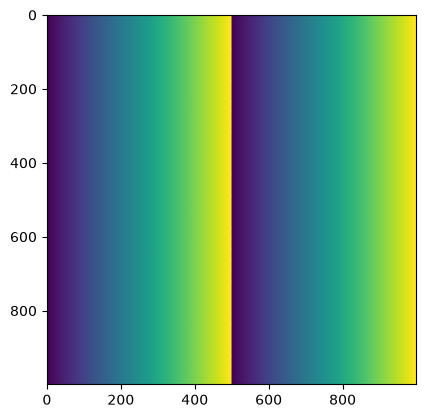

In [11]:
fig, ax = subplots()
ax.imshow(result_array[:,:,5])

In [12]:
print(f"Performances: {NFILES*FRAME_PER_FILE/run_time:.3f} fps")

Performances: 1309.474 fps


In [13]:
release_shared(SHARED_NAME)

## Conclusion
It is possible to achieve 1300 frames per second on a single workstation. 
In this configuration, one million Eiger-4M frames are processed in 12 minutes.

**Energy considerations for processing one million frames:**
- The workstation consumes 700W at the wall outlet, representing 540 kJ (150 Wh) for the data reduction.
- Equivalent processing using only a 6-core workstation takes half a day (40,682 seconds) and consumes 1,561 kJ (433 Wh).
- CPU+GPU-based processing is thus approximately 3× more energy-efficient than CPU-only processing.

**Other considerations:**
- Here, disk reading is fast enough, so there's no need for too many processes per GPU. If disk I/O is slower, adding more processes could be beneficial.
- Since the output array resides in shared memory, sufficient RAM must be available to accommodate it. In this case, 512 GB of memory is available.